<a href="https://colab.research.google.com/github/tomonari-masada/course2026-nlp/blob/main/05_PyTorch_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch入門 (1)


* 今回の授業資料は、以下のPyTorch本家サイトのチュートリアルを参考にしました。
  * https://pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html

* ランタイムの設定でGPUを選択しておいてください。

## テンソルとは
* PyTorchで使われるデータ構造。
  * NumPyのndarrayと、ほぼ同じ感覚で使える。

* NumPyのndarrayとの違い
  * CPU上はもちろん、GPUやその他のアクセラレータ上でも扱える。
  * 自動微分が使える。（そのため、勾配の計算が簡単にできる。）

## 再現性 (reproducibility)
  * 詳しくは https://pytorch.org/docs/stable/notes/randomness.html

In [ ]:
import torch
import numpy as np

torch.manual_seed(0)
np.random.seed(0)

## テンソルの初期化

### 既存のデータから直接テンソルを作る


In [ ]:
data = [[1, 2],[3, 4]]
x_data = torch.tensor(data)

In [ ]:
x_data

### NumPyの配列から作る


In [ ]:
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

In [ ]:
x_np

### 他のテンソルから作る
* 他のテンソルと同じ形状のテンソルを作る。


* 要素が全て1のテンソル

In [ ]:
x_ones = torch.ones_like(x_data) # retains the properties of x_data
print(f"Ones Tensor: \n {x_ones} \n")

* 要素が乱数のテンソル

In [ ]:
x_rand = torch.rand_like(x_data, dtype=torch.float) # overrides the datatype of x_data
print(f"Random Tensor: \n {x_rand} \n")

### 特定の形状を特定の内容で埋めて作る


* 形状の指定
 * Pythonのタプルやリストで指定する。

In [ ]:
shape = (2,3,)
#shape = [2,3] # これでもOK

In [ ]:
rand_tensor = torch.rand(shape)
print(f"Random Tensor: \n {rand_tensor} \n")

In [ ]:
ones_tensor = torch.ones(shape)
print(f"Ones Tensor: \n {ones_tensor} \n")

In [ ]:
zeros_tensor = torch.zeros(shape)
print(f"Zeros Tensor: \n {zeros_tensor}")

## テンソルの属性


* 形状
* データ型
* 保存されているデバイス

In [ ]:
tensor = torch.rand(3,4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

## テンソルの操作

* 詳しくは公式のdocumentationsで。
 * https://pytorch.org/docs/stable/torch.html



### GPU上でのテンソルの操作
* テンソルは、デフォルトではCPU上に作られる。
* そのため、何もしないと、CPU上で演算が行われる。
* GPU上で計算をするには、テンソルをGPUへ移動させておく。

* 巨大なテンソルをCPUとGPUの間で頻繁に行き来させると、時間を食うので、注意。

* テンソルをGPUへ移動させる方法
  * まずCPU上でテンソルを作る。
  * GPUが使えるかどうか確認してから移動させる。

In [ ]:
tensor = torch.rand(3,4)

if torch.cuda.is_available():
  tensor = tensor.to("cuda")
print(tensor)

* 使用するデバイスを変数に保存しておくのも、よく使われる方法。
  * こうすると、CPUを使うコードとGPUを使うコードを、統一して扱える。

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

tensor = torch.rand(3,4)
tensor = tensor.to(device)
print(tensor)

## インデクシングとスライシング
* NumPyとほぼ同じ。


In [ ]:
tensor = torch.cumsum(torch.ones(4, 4), dim=1)
print(tensor)

In [ ]:
print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:, 0]}")
print(f"Last column: {tensor[:, -1]}")

In [ ]:
print(f"First column: {tensor[..., 0]}")
print(f"Last column: {tensor[..., -1]}")

* 同時に複数の要素を上書き

In [ ]:
tensor[:,1] = 0
print(tensor)

### テンソルを結合する

* ``torch.cat``
 * https://pytorch.org/docs/stable/generated/torch.cat.html

* ``torch.stack``
 * https://pytorch.org/docs/stable/generated/torch.stack.html

In [ ]:
tensor = torch.arange(12).reshape(3,4)
print(tensor)

In [ ]:
t1 = torch.cat([tensor, tensor, tensor], dim=1)
print(t1)

### 問: 以下の実行結果を見て、`torch.stack`が何をしているか、説明してみよう。

In [ ]:
t2 = torch.stack([tensor, tensor, tensor], dim=1)
print(t2)

In [ ]:
t3 = torch.stack([tensor, tensor, tensor], dim=0)
print(t3)

## テンソルの演算


In [ ]:
tensor = torch.cumsum(torch.ones(4, 4), dim=1)
print(tensor)

* 転置と行列積

In [ ]:
y1 = tensor @ tensor.T
print(y1)

In [ ]:
y2 = tensor.matmul(tensor.T)
print(y2)

* 既存のテンソルへの計算結果の上書き
 * `out=`で指定する。

In [ ]:
y3 = torch.rand_like(y1)
print(y3)

In [ ]:
torch.matmul(tensor, tensor.T, out=y3)

In [ ]:
# y3が上書きされていることを確認
print(y3)

* 要素ごとの演算

In [ ]:
# This computes the element-wise product. z1, z2, z3 will have the same value
z1 = tensor + tensor
print(z1)
z2 = tensor.add(tensor)
print(z2)

In [ ]:
z3 = torch.rand_like(tensor)
torch.add(tensor, tensor, out=z3)

In [ ]:
print(z3)

## 要素数1のテンソル
* `item()`メソッドでPythonのスカラに変換できる。

In [ ]:
tensor = torch.ones((3,4))
tensor[:,1] = 0
print(tensor)

In [ ]:
agg = tensor.sum()
print(agg)

In [ ]:
agg_item = agg.item()
print(agg_item)
print(type(agg_item))

## in-place演算
* 演算結果が演算対象のテンソルに上書きされる演算
* PyTorchでは``_``という接尾辞で表される。
 * 例えば ``x.copy_(y)``, ``x.t_()``などは``x``の内容を上書きする。



In [ ]:
tensor = torch.cumsum(torch.ones(4, 4), dim=1)
print(tensor)

In [ ]:
tensor.add_(5)
print(tensor)

* in-place演算はメモリの節約になるが、自動微分でトラブルのもと。
* PyTorch本家サイトはHence, their use is discouraged.と言っている。



## NumPyとの連携
* PyTorchのテンソルとNumPyのndarrayは相互に変換できる。


### TensorからNumPyの配列へ



In [ ]:
t = torch.ones(5)
print(f"t: {t}")
n = t.numpy()
print(f"n: {n}")

* テンソルをin-place演算で変更すると、NumPyの配列も変わるので、注意。



In [ ]:
t.add_(1)
print(f"t: {t}")
print(f"n: {n}")

In [ ]:
t = torch.ones(5)
n = t.numpy()
t += 1
print(f"t: {t}")
print(f"n: {n}")

### 問: 以下のPyTorchのコードの結果がなぜそうなるか、説明してみよう。

In [ ]:
t = torch.ones(5)
n = t.numpy()
t = t + 1
print(f"t: {t}")
print(f"n: {n}")

### NumPyの配列からテンソルへ



In [ ]:
n = np.ones(5)
print(f"n: {n}")
t = torch.from_numpy(n)
print(f"t: {t}")

* NumPyの配列をin-place演算で変えるとテンソルも変わるので、注意。



In [ ]:
np.add(n, 1, out=n)
print(f"t: {t}")
print(f"n: {n}")

In [ ]:
n = np.ones(5)
t = torch.from_numpy(n)
n += 1
print(f"t: {t}")
print(f"n: {n}")

In [ ]:
n = np.ones(5)
t = torch.from_numpy(n)
n = n + 1
print(f"t: {t}")
print(f"n: {n}")

## 自動微分

* ここからはPyTorchのTensorsというチュートリアルにはない部分です。

### 微分できるテンソルを作る
* requires_gradをTrueに設定してテンソルを作る

In [ ]:
import torch

x = torch.ones(2, 2, requires_grad=True)
print(x)
print(x.requires_grad)

tensor([[1., 1.],
        [1., 1.]], requires_grad=True)
True


* テンソルを作った後でrequires_gradをTrueにすることもできる。

In [ ]:
a = torch.randn(2, 2)
print(a)
print(a.requires_grad)

tensor([[ 1.0080,  0.3392],
        [ 0.4576, -1.2136]])
False


In [ ]:
a.requires_grad_(True)
print(a.requires_grad)

True


### 計算グラフ
* 微分できるテンソルを含む計算を行うと、計算グラフが作られる。

In [ ]:
x = torch.ones((2, 2), requires_grad=True)
print(x)
y = x * x * 2
print(y)
z = y.mean()
print(z)

tensor([[1., 1.],
        [1., 1.]], requires_grad=True)
tensor([[2., 2.],
        [2., 2.]], grad_fn=<MulBackward0>)
tensor(2., grad_fn=<MeanBackward0>)


In [ ]:
print(f"Gradient function for z = {z.grad_fn}")

Gradient function for z = <MeanBackward0 object at 0x7ad7423820e0>


### GPUでの自動微分

* デバイスの設定

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


* forward pass

In [ ]:
x = torch.ones((2, 2), device=device, requires_grad=True)
print(x)
y = x * x * 2
print(y)
z = y.mean()
print(z)

tensor([[1., 1.],
        [1., 1.]], device='cuda:0', requires_grad=True)
tensor([[2., 2.],
        [2., 2.]], device='cuda:0', grad_fn=<MulBackward0>)
tensor(2., device='cuda:0', grad_fn=<MeanBackward0>)


In [ ]:
print(f"Gradient function for z = {z.grad_fn}")

Gradient function for z = <MeanBackward0 object at 0x7ad72ab50d30>


* backward pass

In [ ]:
z.backward()

* 偏微分の結果の確認

In [ ]:
x.grad

tensor([[1., 1.],
        [1., 1.]], device='cuda:0')

### 問: なぜ上の結果になっているか、説明してみよう。

$f(x_1,x_2,x_3,x_4) = \frac{1}{4}(2 x_1^2 + 2x_2^2 + 2x_3^2 + 2x_4^2)$

$\frac{\partial f}{\partial x_1} = \frac{1}{4}4x_1 = x_1$

## 計算グラフの可視化

In [ ]:
!pip install torchviz

In [ ]:
from torchviz import make_dot

In [ ]:
x = torch.ones((2, 2), device=device, requires_grad=True)
print(x)
y = x * x * 2
print(y)
z = y.mean()
print(z)

tensor([[1., 1.],
        [1., 1.]], device='cuda:0', requires_grad=True)
tensor([[2., 2.],
        [2., 2.]], device='cuda:0', grad_fn=<MulBackward0>)
tensor(2., device='cuda:0', grad_fn=<MeanBackward0>)


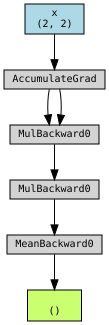

In [ ]:
make_dot(z, params={'x':x})

# （発展編）高階微分

* PyTorchの`torch.autograd`を利用すると、高階微分の計算ができる。

## （応用例）スコア・マッチングによる確率分布のパラメータ推定
* スコア・マッチングについては、下記の論文を参照。
  * https://jmlr.org/papers/volume6/hyvarinen05a/hyvarinen05a.pdf
* 式(4)を利用して、パラメータ推定を行う。
  * 2階偏微分の計算が必要。
  * そこで`torch.autograd`を使う。

### 1. 正規分布の場合

* 人工データの生成

In [ ]:
x_obs = torch.randn(1000)

In [ ]:
x_obs[:30]

tensor([-0.8028,  1.2154, -0.7536, -1.1893, -0.4055, -1.3194,  0.2917, -0.7067,
        -1.7455,  0.4269,  0.3396, -0.9283,  1.6653,  2.5453, -0.5535, -0.1125,
        -0.6034, -1.1217,  1.0055, -0.9495,  0.4159,  1.5249, -0.6305,  1.1616,
        -1.0015, -0.0700, -0.2487,  0.7451, -0.0227, -0.1993])

* 規格化されていない対数密度関数

In [ ]:
def log_unnormalized_density(x, a, b):
  return - (x - a) ** 2 / (2 * b ** 2)

* スコア・マッチングによるパラメータ更新を行う関数
  * パラメータは平均と標準偏差。

In [ ]:
def update(a, b, learning_rate=0.01):
  x = x_obs.clone().requires_grad_(True)
  log_q = log_unnormalized_density(x, a, b)
  grad_outputs = torch.ones_like(log_q)
  psi = torch.autograd.grad(log_q, x, grad_outputs=grad_outputs, create_graph=True)
  d_psi = torch.autograd.grad(psi[0], x, grad_outputs=grad_outputs, create_graph=True)
  J = (d_psi[0] + psi[0] ** 2 / 2).mean()
  dJ = torch.autograd.grad(J, [a, b])
  with torch.no_grad():
    a -= learning_rate * dJ[0]
    b -= learning_rate * dJ[1]
  return a, b

* 推定すべきパラメータを適当に初期化

In [ ]:
a = torch.tensor(0.5, requires_grad=True)
b = torch.tensor(1.2, requires_grad=True)

* 目的関数を最小化する

In [ ]:
for i in range(1000):
  a, b = update(a, b, learning_rate=0.1)
  if i % 100 == 0:
    print(a, b)

tensor(0.4751, requires_grad=True) tensor(1.1787, requires_grad=True)
tensor(-0.0170, requires_grad=True) tensor(0.9529, requires_grad=True)
tensor(-0.0170, requires_grad=True) tensor(0.9529, requires_grad=True)
tensor(-0.0170, requires_grad=True) tensor(0.9529, requires_grad=True)
tensor(-0.0170, requires_grad=True) tensor(0.9529, requires_grad=True)
tensor(-0.0170, requires_grad=True) tensor(0.9529, requires_grad=True)
tensor(-0.0170, requires_grad=True) tensor(0.9529, requires_grad=True)
tensor(-0.0170, requires_grad=True) tensor(0.9529, requires_grad=True)
tensor(-0.0170, requires_grad=True) tensor(0.9529, requires_grad=True)
tensor(-0.0170, requires_grad=True) tensor(0.9529, requires_grad=True)


In [ ]:
x_obs.mean(), x_obs.std(unbiased=False)

(tensor(0.0366), tensor(0.9794))

### 2. シグモイド・ベータ分布の場合

In [ ]:
from scipy.stats import beta

a = 5.0
b = 2.0
x_obs = beta.rvs(a, b, size=1000, random_state=0)
x_obs = torch.from_numpy(x_obs)

In [ ]:
x_obs[:30]

tensor([0.8111, 0.9347, 0.6636, 0.7807, 0.7272, 0.8600, 0.2808, 0.9659, 0.6685,
        0.9391, 0.6770, 0.8665, 0.7584, 0.5842, 0.5739, 0.6686, 0.7341, 0.9167,
        0.4556, 0.7775, 0.8574, 0.6982, 0.4521, 0.9401, 0.8421, 0.5035, 0.6654,
        0.6882, 0.4267, 0.8138], dtype=torch.float64)

* $x = \sigma(y)$と変数変換する。ここで$\sigma$はシグモイド関数。

In [ ]:
y_obs = torch.special.logit(x_obs, eps=1e-6)

In [ ]:
y_obs[:30]

tensor([ 1.4569,  2.6617,  0.6792,  1.2699,  0.9804,  1.8153, -0.9405,  3.3429,
         0.7016,  2.7365,  0.7400,  1.8703,  1.1440,  0.3399,  0.2979,  0.7019,
         1.0156,  2.3977, -0.1782,  1.2512,  1.7940,  0.8386, -0.1923,  2.7536,
         1.6737,  0.0140,  0.6875,  0.7915, -0.2951,  1.4750],
       dtype=torch.float64)

* https://www.tensorflow.org/probability/api_docs/python/tfp/distributions/SigmoidBeta
  * $f_Y(y)=f_X(\sigma(y)) |\frac{d\sigma(y)}{dy}|$.
  * For $\sigma(y)$, we obtain $\frac{d\sigma(y)}{dy} = \sigma(y) (1 - \sigma(y)) \geq 0$.
  * Therefore, $f_Y(y)=f_X(\sigma(y)) \sigma(y) (1 - \sigma(y)) = \sigma(y)^{a - 1} (1 - \sigma(y))^{b - 1}\sigma(y) (1 - \sigma(y)) = \sigma(y)^a (1 - \sigma(y))^b$.

In [ ]:
def log_unnormalized_density(y, a, b):
  return a * torch.log(torch.sigmoid(y)) + b * torch.log(1.0 - torch.sigmoid(y))

In [ ]:
def update(a, b, learning_rate=0.01):
  y = y_obs.clone().requires_grad_(True)
  log_q = log_unnormalized_density(y, a, b)
  grad_outputs = torch.ones_like(log_q)
  psi = torch.autograd.grad(log_q, y, grad_outputs=grad_outputs, create_graph=True)
  d_psi = torch.autograd.grad(psi[0], y, grad_outputs=grad_outputs, create_graph=True)
  J = (d_psi[0] + psi[0] ** 2 / 2).mean()
  dJ = torch.autograd.grad(J, [a, b])
  with torch.no_grad():
    a -= learning_rate * dJ[0]
    b -= learning_rate * dJ[1]
  return a, b

In [ ]:
a = torch.tensor(0.5, requires_grad=True)
b = torch.tensor(1.2, requires_grad=True)

In [ ]:
for i in range(3000):
  a, b = update(a, b, learning_rate=0.1)
  if i % 100 == 0:
    print(a, b)

tensor(0.5344, requires_grad=True) tensor(1.1646, requires_grad=True)
tensor(2.2666, requires_grad=True) tensor(1.0541, requires_grad=True)
tensor(3.2186, requires_grad=True) tensor(1.4143, requires_grad=True)
tensor(3.8315, requires_grad=True) tensor(1.6473, requires_grad=True)
tensor(4.2264, requires_grad=True) tensor(1.7975, requires_grad=True)
tensor(4.4808, requires_grad=True) tensor(1.8942, requires_grad=True)
tensor(4.6447, requires_grad=True) tensor(1.9565, requires_grad=True)
tensor(4.7504, requires_grad=True) tensor(1.9967, requires_grad=True)
tensor(4.8184, requires_grad=True) tensor(2.0225, requires_grad=True)
tensor(4.8622, requires_grad=True) tensor(2.0392, requires_grad=True)
tensor(4.8905, requires_grad=True) tensor(2.0499, requires_grad=True)
tensor(4.9087, requires_grad=True) tensor(2.0569, requires_grad=True)
tensor(4.9204, requires_grad=True) tensor(2.0613, requires_grad=True)
tensor(4.9279, requires_grad=True) tensor(2.0642, requires_grad=True)
tensor(4.9328, requi